Import de dataset y librerias

In [1]:
import pandas as pd
import numpy as np
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from skforecast.preprocessing import RollingFeatures
import seaborn as sns

dataset = 'CTC_processed.csv'
                              
data = pd.read_csv( #Cargar el csv
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

datet = data["datetime"].iloc[int(len(data) * 0.8):] #reservamos las fechas para el dataframe de promedios

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

data = data.dropna(how='all') #eliminamos NaN

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'month', 'day', 'hour', 'minute'] #variables exogenas

Dividimos en train y test

In [2]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size] #80% train
data_test  = data.iloc[train_size:] #20% test

Escalamos los datos.

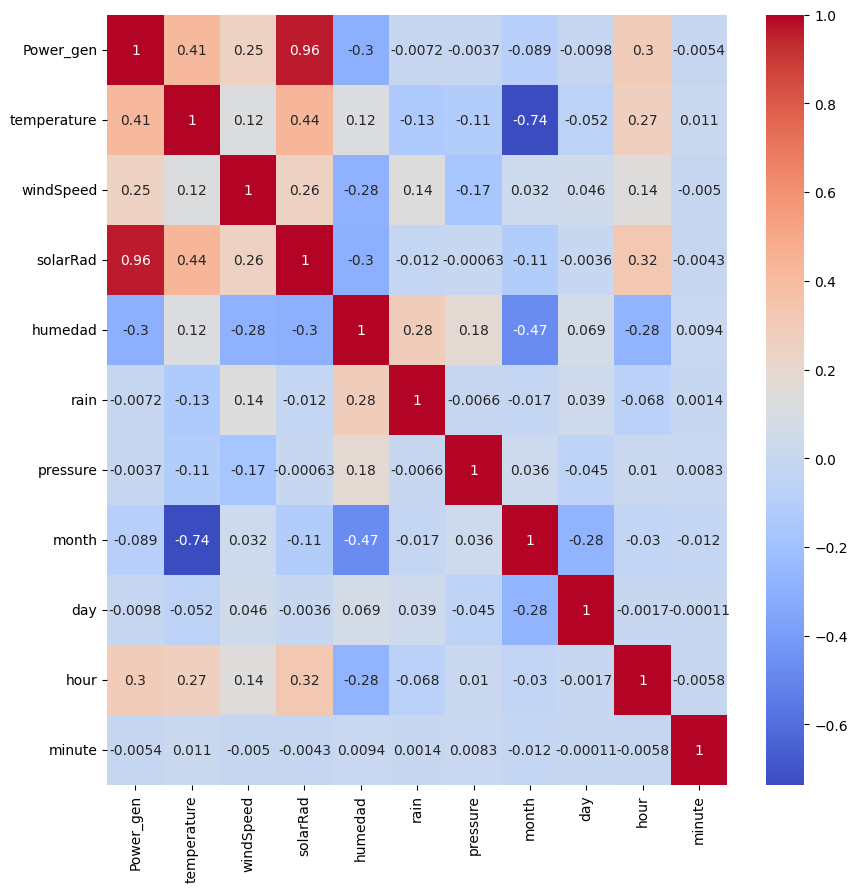

In [3]:
scaler = MinMaxScaler()
#entrenamiento
train_scaled = data_train.copy()
train_scaled[exogenas] = scaler.fit_transform(data_train[exogenas])

corr_train = train_scaled.corr(method ='spearman')

#test
test_scaled = data_test.copy()
test_scaled[exogenas] = scaler.fit_transform(data_test[exogenas])

corr_test = test_scaled.corr(method ='spearman')

plt.figure(figsize=(10, 10))
sns.heatmap(corr_test, annot=True, cmap='coolwarm')

plt.show()

Evolucion de las variables exogenas

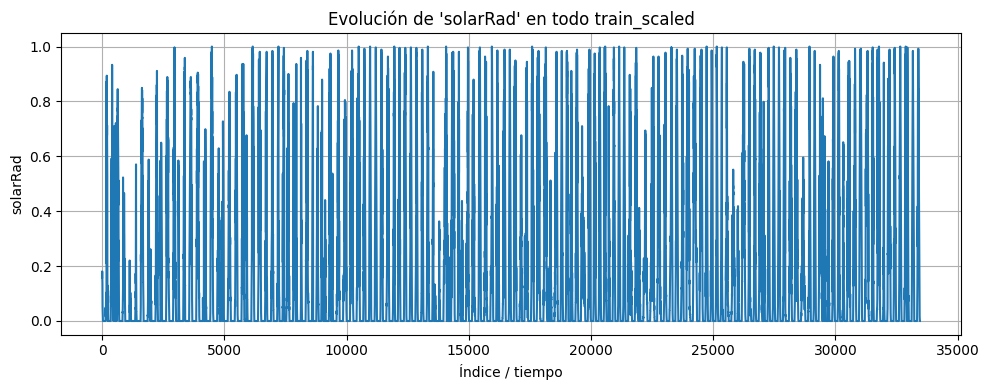

In [4]:
var = "solarRad"  #variable a analizar

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index, train_scaled[var])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en todo train_scaled")
plt.grid(True)
plt.tight_layout()
plt.show()


Valores de las exogenas para un dia en concreto

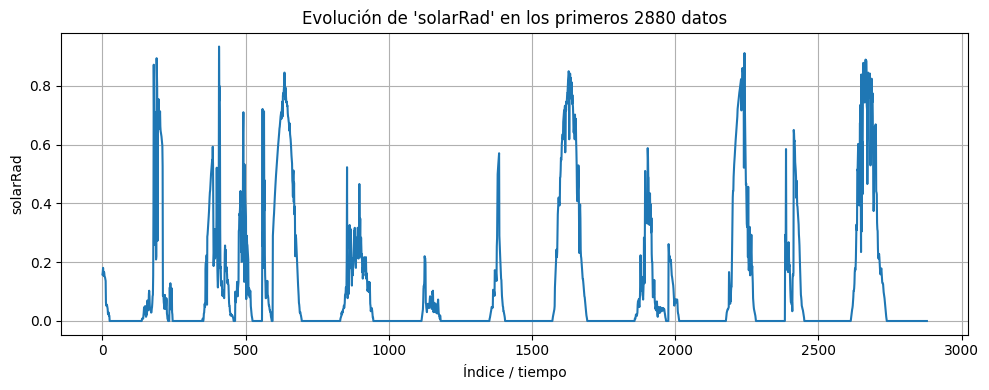

In [5]:
pasos_dia = 10 * (24 * 60 // 5)   #288 primer dia de data_train (datos cada 5 minutos)

plt.figure(figsize=(10, 4))
plt.plot(train_scaled.index[:pasos_dia], train_scaled[var].iloc[:pasos_dia])
plt.xlabel("Índice / tiempo")
plt.ylabel(var)
plt.title(f"Evolución de '{var}' en los primeros {pasos_dia} datos")
plt.grid(True)
plt.tight_layout()
plt.show()


El primer paso es crear el forecaster.

In [6]:
window_features = RollingFeatures(
                      stats        = ['mean', 'min', 'max'], 
                      window_sizes = [20, 20, 20]
                  ) #media, minimo y maximo de los ultimos 20 valores

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 400, subsample = 0.6, random_state = 42, base_score = 0.0,
                             colsample_bytree=0.8),
    lags = 7, #7 vlaores previos para predecir el actual
    window_features=window_features
)

Entrenamos el modelo.

In [7]:
X_test, y_test = forecaster.create_train_X_y(y=test_scaled['Power_gen'], exog=test_scaled[exogenas]) #matrices test
X_train, y_train = forecaster.create_train_X_y(y=train_scaled['Power_gen'], exog=train_scaled[exogenas]) #matrices train

forecaster.fit(y=train_scaled['Power_gen'], exog=train_scaled[exogenas]) #entrenar
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: ['roll_mean_20', 'roll_min_20', 'roll_max_20'] 
Window size: 20 
Series name: Power_gen 
Exogenous included: True 
Exogenous names: 
    temperature, solarRad, humedad, windSpeed, rain, pressure, month, day, hour,
    minute 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 33455] 
Training index type: RangeIndex 
Training index frequency: 1 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': 0.0, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    0.01, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 9, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 400, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': 0.6, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-01-15 12:56:26 
Last fit date: 2026-01-15 12:56:32 
Skforecast version: 0.19.0 
Python version: 3.14.1 
Forecaster id: None

Comprobamos si hay overfitting y entrenamos. El early_stop = 50, por lo que el modelo se detendrá cuando no haya mejorado en 50 iteraciones el valor de validación. La reducción del error segun avanza el train indica la efectiva eliminacion de perdidas. Alcanza una estabilización al final, lo que significa el final del proceso de entrenamiento. El comportamiento del modelo en entrenamiento y validacion es consistente, lo que confirma la no presencia de sobreentrenamiento en los datos.

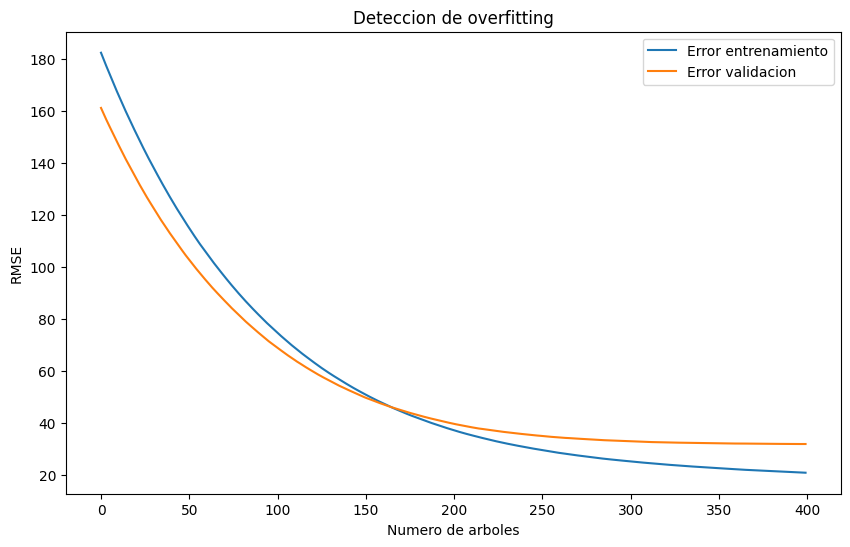

In [8]:
model = forecaster.estimator

model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose = False)

results = model.evals_result()

#print(f"Mejor iteracion: {forecaster.estimator.best_iteration}")
plt.figure(figsize=(10,6))
plt.plot(results['validation_0']['rmse'], label='Error entrenamiento')
plt.plot(results['validation_1']['rmse'], label='Error validacion')
plt.xlabel('Numero de arboles')
plt.ylabel('RMSE')
plt.title('Deteccion de overfitting')
plt.legend()
plt.show()

Obtenemos las variables mas importantes en el forecaster

In [9]:
importancia = forecaster.get_feature_importances()
print(importancia)

         feature  importance
0          lag_1    0.639488
1          lag_2    0.158001
11      solarRad    0.054222
18          hour    0.032133
2          lag_3    0.013434
16         month    0.012951
8    roll_min_20    0.009755
5          lag_6    0.008500
6          lag_7    0.008080
9    roll_max_20    0.007707
3          lag_4    0.007335
7   roll_mean_20    0.007190
4          lag_5    0.006972
14          rain    0.005875
12       humedad    0.005224
10   temperature    0.004953
17           day    0.004858
13     windSpeed    0.004595
19        minute    0.004395
15      pressure    0.004332


Usamos SHAP para crear los datos de entrenamiento

In [10]:
x_train, y_train = forecaster.create_train_X_y(
    y=train_scaled['Power_gen'],
    exog=train_scaled[exogenas]
)

print(x_train.head()) 
print(y_train.head()) 

    lag_1  lag_2  lag_3  lag_4  lag_5  lag_6  lag_7  roll_mean_20  \
20    0.0   39.0   39.0   39.0   39.0   39.0   39.0         53.45   
21    0.0    0.0   39.0   39.0   39.0   39.0   39.0         50.20   
22    0.0    0.0    0.0   39.0   39.0   39.0   39.0         46.70   
23    0.0    0.0    0.0    0.0   39.0   39.0   39.0         42.60   
24    0.0    0.0    0.0    0.0    0.0   39.0   39.0         38.70   

    roll_min_20  roll_max_20  temperature  solarRad  humedad  windSpeed  rain  \
20          0.0         82.0     0.545107  0.022187     0.00   0.879562   0.0   
21          0.0         82.0     0.541284  0.025357     0.00   0.645985   0.0   
22          0.0         82.0     0.541284  0.028526     0.00   0.762774   0.0   
23          0.0         78.0     0.545107  0.017433     0.00   0.879562   0.0   
24          0.0         70.0     0.548930  0.017433     0.02   0.879562   0.0   

    pressure  month       day      hour    minute  
20  0.181818    0.0  0.766667  0.695652  0.847

Explainer del SHAP

In [11]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

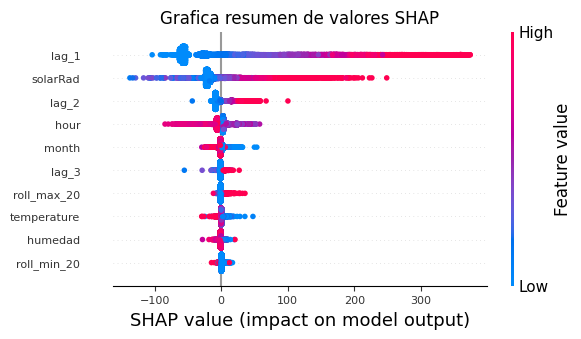

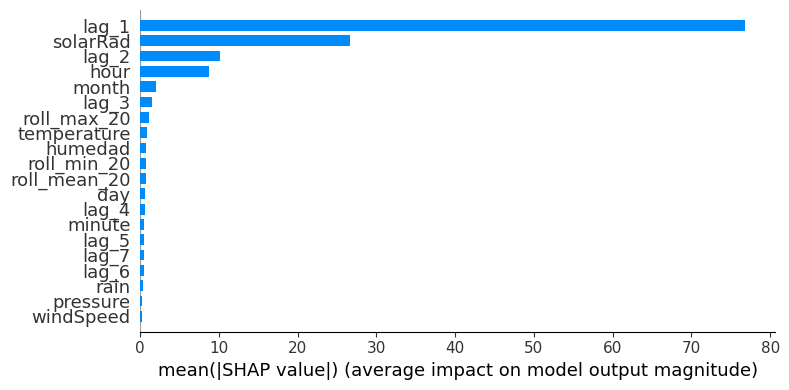

In [12]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(8, 4))
plt.show()

Grafica de dependencia

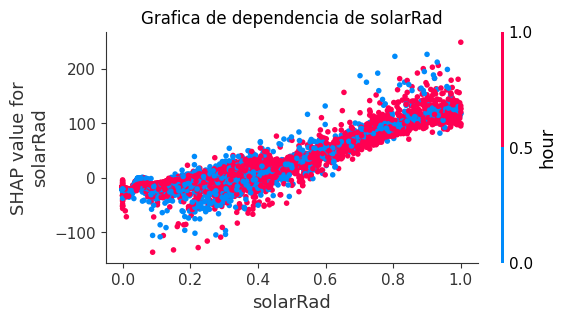

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Primero, veremos las explicaciones de SHAP para predicciones de las proximas 8364 muestras (data_test)

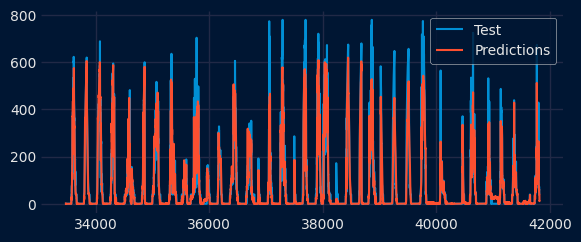

In [14]:
pred = forecaster.predict(steps=len(test_scaled), exog=test_scaled[exogenas])

set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
test_scaled['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Graficas de dependencia parcial.

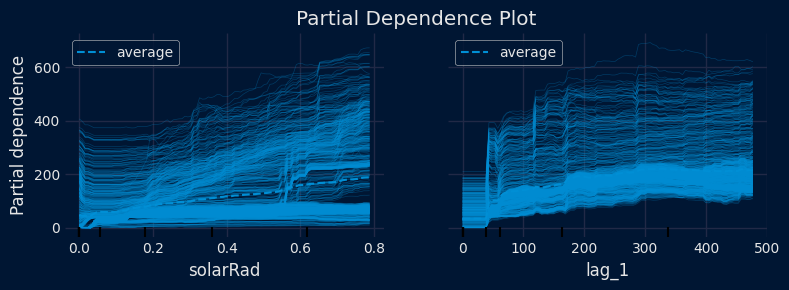

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [16]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 17.0592
Mean Squared Error (MSE): 1704.9633
Root Mean Squared Error (RMSE): 41.2912
Coeficiente de determinación (R^2): 0.9176


Añadimos una variable extra, la irrandiancia ideal, de forma que ayude al modelo a saber hasta que valor podría llegar a ascender.

In [17]:
t_min = data["hour"] * 60 + data["minute"] #minutos desde medianoche
t_day = 24 * 60 #minutos al dia

t_mid = 13 * 60 #mediodia solar   
x = (t_min - t_mid) / (t_day / 2)   

irr_ideal_norm = np.clip(1 - x**2, 0, 1) #1-x^2, valores [0,1]

IRR_MAX = data["solarRad"].max() #maxima solarRad
train_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm
test_scaled["irr_ideal"] = IRR_MAX * irr_ideal_norm

In [18]:
exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed',
            'rain', 'pressure', 'month', 'day', 'hour', 'minute',
             'irr_ideal'] #irr_ideal añadida a las exogenas

forecaster.fit(y=train_scaled["Power_gen"],
               exog=train_scaled[exogenas]) #volvemos a entrenar

pred = forecaster.predict(steps=len(test_scaled),
                          exog=test_scaled[exogenas]) #volvemos a predecir


Nuevas métricas de la predicción, ligeramente mejores.

In [19]:
y_test = test_scaled['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}") #MAE = Error medio en la predicción
print(f"Mean Squared Error (MSE): {mse:.4f}") #MSE = Error cuadrático medio en la predicción
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}") #RMSE = Raíz del error cuadrático medio en la predicción
print(f"Coeficiente de determinación (R^2): {r2:.4f}") #R^2 = Coeficiente de determinación


Mean Absolute Error (MAE): 16.5215
Mean Squared Error (MSE): 1631.2590
Root Mean Squared Error (RMSE): 40.3888
Coeficiente de determinación (R^2): 0.9212


Predicción para un día

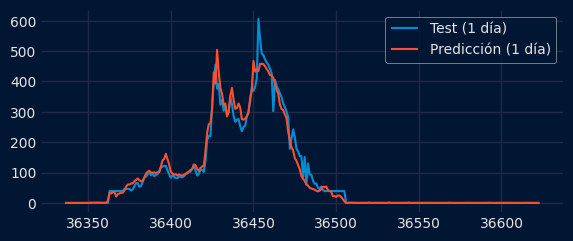

In [20]:
pasos_dia = 24 * 60 // 5   #288

#Ahora recorta solo un día para graficar
idx_ini = 10 * pasos_dia #dia en concreto
y_real_dia = test_scaled['Power_gen'].iloc[idx_ini:idx_ini + pasos_dia]
pred_dia   = pred.iloc[idx_ini:idx_ini + pasos_dia]

fig, ax = plt.subplots(figsize=(6, 2.5))
y_real_dia.plot(ax=ax, label='Test (1 día)')
pred_dia.plot(ax=ax, label='Predicción (1 día)', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()


Predicción para dos días

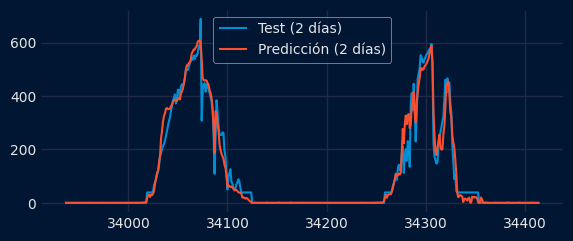

In [21]:
pasos_dia = 2 * (20 * 60 // 5)

#Ahora recorta solo un día para graficar
idx_ini = 1 * pasos_dia #dias en concreto
y_real_dia = test_scaled['Power_gen'].iloc[idx_ini:idx_ini + pasos_dia]
pred_dia   = pred.iloc[idx_ini:idx_ini + pasos_dia]

fig, ax = plt.subplots(figsize=(6, 2.5))
y_real_dia.plot(ax=ax, label='Test (2 días)')
pred_dia.plot(ax=ax, label='Predicción (2 días)', linestyle='-')
ax.set_xlabel(None)
ax.legend()
plt.show()

Comparativa realidad vs prediccion

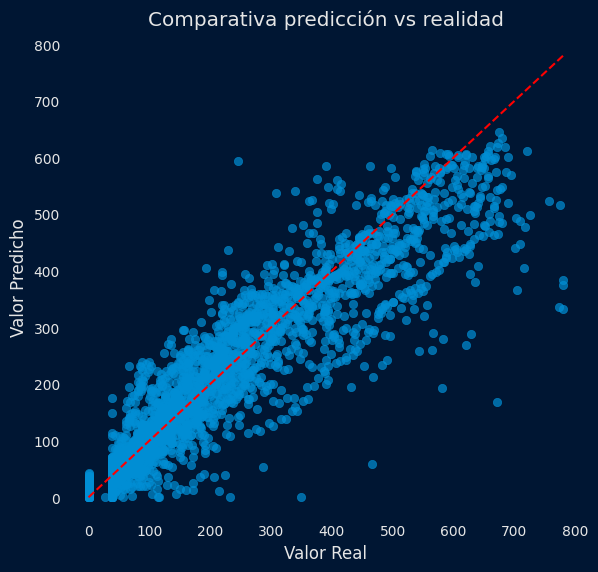

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()

Tratamiento de ceros

In [23]:
error_cero = np.where((y_test == 0) & (pred > 0))[0] #errores en 0 mayores que el MAE

print(f"Se encontraron {len(error_cero)} errores mayores que el mae en el valor cero")

print(pred.iloc[error_cero])

Se encontraron 3104 errores mayores que el mae en el valor cero
33456     0.083296
33457     0.083296
33458     0.083296
33459     0.083826
33460     0.083826
           ...    
41731     8.624807
41732    10.961976
41733    11.328688
41734    25.986856
41735    37.251801
Name: pred, Length: 3104, dtype: float64


Cálculo de medias mañana, tarde y diaria.

In [24]:
pred_clas = pd.DataFrame({
    'datetime': datet,
    'prediction': pred.values
})

h = pred_clas['datetime'].dt.hour
condiciones = [(h >= 7) & (h < 13), (h >= 13) & (h < 20)] #[7,13) mañana, [13,20) tarde
elecciones = ['mañana', 'tarde']

pred_clas['periodo'] = np.select(condiciones, elecciones, default=None)
pred_clas = pred_clas.dropna(subset=['periodo'])

pred_clas['dia'] = pred_clas['datetime'].dt.date

media_diaria_total = pred_clas.groupby('dia')['prediction'].mean().reset_index() #media diaria
media_diaria_total.columns = ['dia', 'media']

pred_clas = pred_clas.pivot_table(index='dia', columns='periodo', values='prediction', aggfunc='mean').reset_index()

pred_clas.columns.name = None

pred_clas = pred_clas.merge(media_diaria_total, on='dia')

pred_clas.dropna(inplace=True)

pred_clas.head()

,dia,mañana,tarde,media
0,2025-08-09,207.978989,185.414501,198.702477
1,2025-08-10,282.911455,185.213853,243.832414
2,2025-08-11,299.637896,213.071747,264.849630
3,2025-08-12,237.437343,141.474292,191.617148
4,2025-08-13,43.158797,137.025899,89.093762


Graficar.

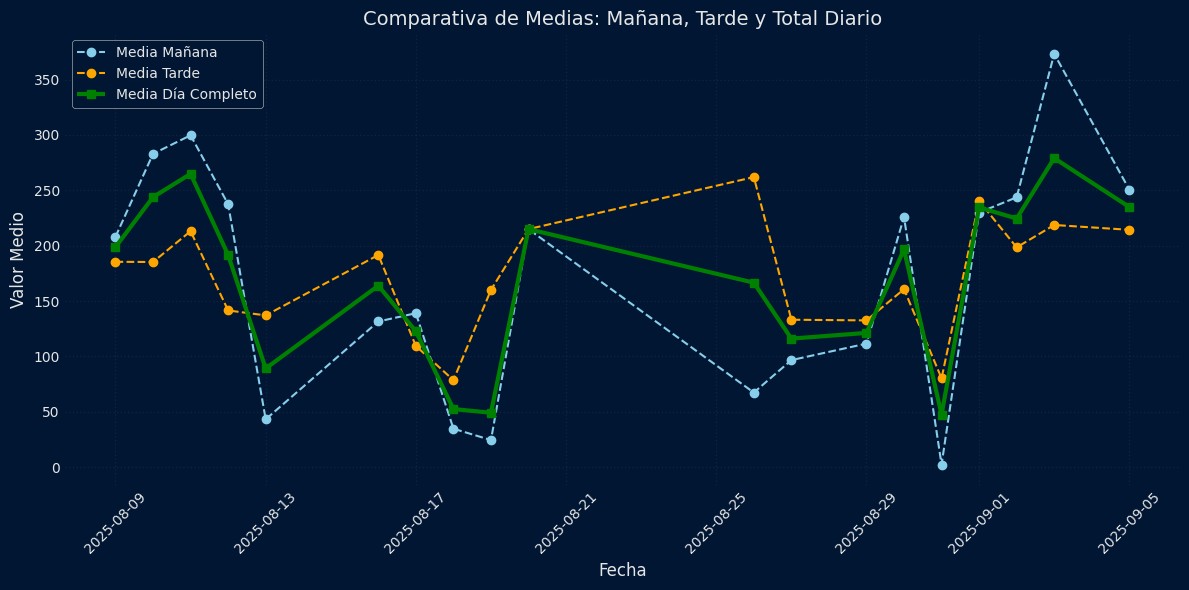

In [25]:
plt.figure(figsize=(12, 6))

fecha_limite = pd.to_datetime('2025-09-05').date()
data_plot = pred_clas[pred_clas['dia'] <= fecha_limite]

plt.plot(data_plot['dia'], data_plot['mañana'], label='Media Mañana', color='skyblue', marker='o', linestyle='--')
plt.plot(data_plot['dia'], data_plot['tarde'], label='Media Tarde', color='orange', marker='o', linestyle='--')
plt.plot(data_plot['dia'], data_plot['media'], label='Media Día Completo', color='green', linewidth=3, marker='s')
plt.title('Comparativa de Medias: Mañana, Tarde y Total Diario', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Valor Medio', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

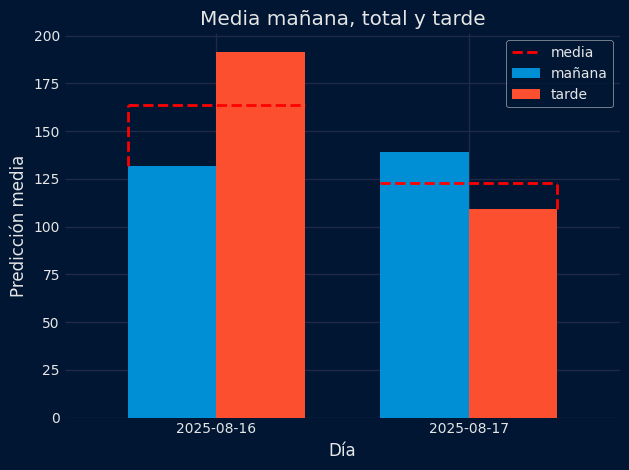

In [26]:
fecha = '2025-08-16'

dia = pd.to_datetime(fecha).date()
dia_sig = (pd.to_datetime(fecha) + pd.Timedelta(days=1)).date()
dias = [dia, dia_sig]

data_plot = pred_clas[pred_clas['dia'].isin(dias)].copy()
data_plot = data_plot.set_index('dia')

ax = data_plot[['mañana', 'tarde']].plot(kind='bar', width=0.7)

bar_width = 0.35

for i, (idx, row) in enumerate(data_plot.iterrows()):
    media = row['media']
    if row['mañana'] < row['tarde']:
        min_val = row['mañana']
        x_pos = i - bar_width
    else:
        min_val = row['tarde']
        x_pos = i + bar_width
    
    ax.vlines(x=x_pos, ymin=min_val, ymax=media, 
              colors='red', linewidth=2, linestyles='dashed')
    
    ax.hlines(y=media, xmin=i-0.35, xmax=i+0.35, 
              colors='red', linewidth=2, linestyles='dashed',
              label='media' if i == 0 else '')

ax.set_xlabel('Día')
ax.set_ylabel('Predicción media')
ax.set_title('Media mañana, total y tarde')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Seleccionar día en concreto.

In [ ]:
fecha = pd.to_datetime('2025-08-17').date()

print(f"Media por la mañana del {fecha}: {pred_clas[pred_clas['dia'] == fecha]['mañana'].values[0]:.2f}")
print(f"Media por la tarde del {fecha}: {pred_clas[pred_clas['dia'] == fecha]['tarde'].values[0]:.2f}")
print(f"Media total del {fecha}: {pred_clas[pred_clas['dia'] == fecha]['media'].values[0]:.2f}")

Media por la mañana del 2025-08-17: 138.99
Media por la tarde del 2025-08-17: 109.40
Media total del 2025-08-17: 122.63
